In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

In [2]:

import tensorflow as tf
tf.random.set_seed(3)

from tensorflow import keras
from keras.datasets import mnist

from tensorflow.math import confusion_matrix

In [3]:
# loading mnist data
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


In [4]:
type(X_train)

numpy.ndarray

In [5]:
# shape of numpy arrays
(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

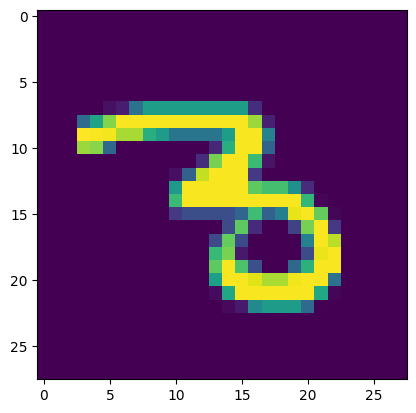

3


In [6]:
img= plt.imshow(X_train[30])
plt.show()
# print corresponding label
print(Y_train[30])

In [7]:
# unique values in Y_train

np.unique(Y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [8]:
# scaling the values

X_train= X_train/255
X_test=X_test/255

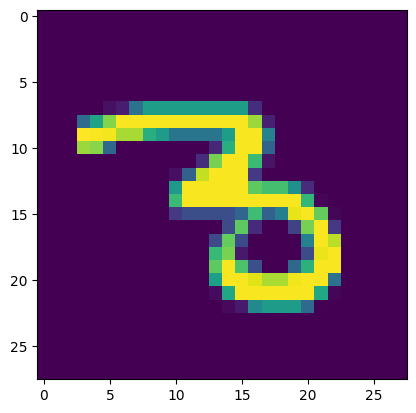

3


In [9]:
img= plt.imshow(X_train[30])
plt.show()
# print corresponding label
print(Y_train[30])

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import metrics
import tensorflow as tf


In [14]:
# Convert labels to categorical (one-hot encoding)
y_train = to_categorical(Y_train, 10)
y_test = to_categorical(Y_test, 10)

In [15]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [23]:

model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(28, 28)), # RNN layer with 28 timesteps and 28 input dimensions
    Dense(50, activation='relu'), # Fully connected layer with 50 neurons
    Dense(50, activation='relu'), # Fully connected layer with 50 neurons
    Dense(10, activation='softmax') # Output layer with 10 neurons for classification
])


c:\Users\mishr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy', 
                       metrics.Precision(name='precision'), 
                       metrics.Recall(name='recall')])

In [25]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6405 - loss: 1.0185 - precision: 0.7875 - recall: 0.5217 - val_accuracy: 0.9001 - val_loss: 0.3391 - val_precision: 0.9286 - val_recall: 0.8701
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9038 - loss: 0.3196 - precision: 0.9259 - recall: 0.8835 - val_accuracy: 0.9240 - val_loss: 0.2585 - val_precision: 0.9368 - val_recall: 0.9118
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9241 - loss: 0.2518 - precision: 0.9400 - recall: 0.9115 - val_accuracy: 0.9441 - val_loss: 0.1919 - val_precision: 0.9528 - val_recall: 0.9353
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9360 - loss: 0.2138 - precision: 0.9489 - recall: 0.9258 - val_accuracy: 0.9438 - val_loss: 0.1970 - val_precision: 0.9515 - val_recall: 0.9359
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9427 - loss: 0.1914 - precision: 0.9536 - recall: 0.9340 - val_accuracy: 0.9485 -

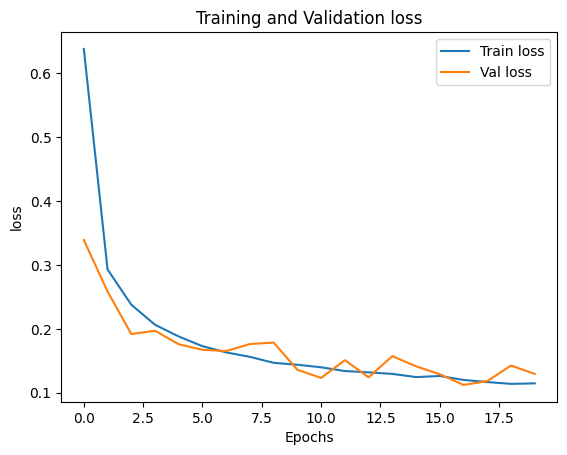

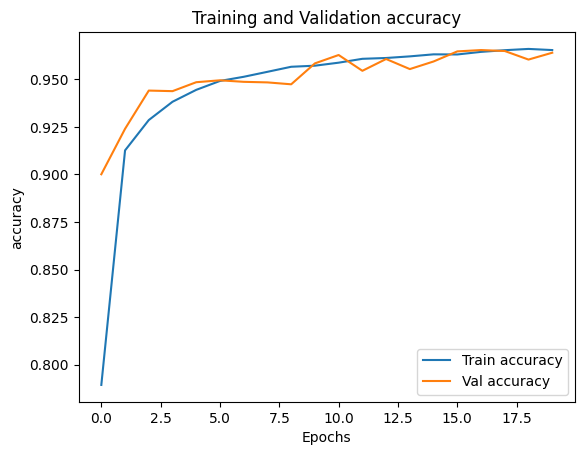

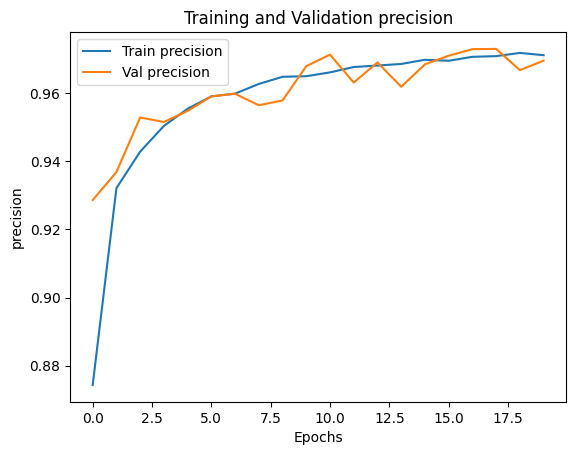

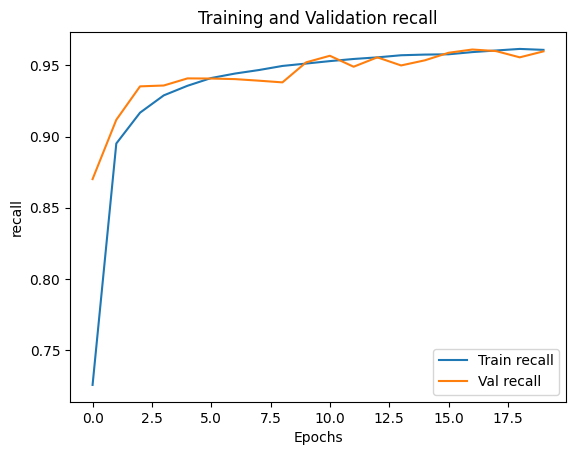

In [26]:
# Plotting training & validation metrics
def plot_metrics(history):
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    for metric in metrics:
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'Training and Validation {metric}')
        plt.xlabel('Epochs')
        plt.ylabel(metric)
        plt.legend()
        plt.show()

plot_metrics(history)

In [27]:
# Evaluate the model
results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")
print(f"Test Precision: {results[2]}")
print(f"Test Recall: {results[3]}")

Test Loss: 0.129432812333107
Test Accuracy: 0.9639999866485596
Test Precision: 0.9694980382919312
Test Recall: 0.9599000215530396


In [28]:
model.save("modelSimpleRNN.keras")

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(28, 28)), # RNN layer with 28 timesteps and 28 input dimensions
    Dense(50, activation='relu'), # Fully connected layer with 50 neurons
    Dense(50, activation='relu'), # Fully connected layer with 50 neurons
    Dense(10, activation='softmax') # Output layer with 10 neurons for classification
])

# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy', 
                       metrics.Precision(name='precision'), 
                       metrics.Recall(name='recall')])

# Implement early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


c:\Users\mishr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
# Train the model
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])


Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6435 - loss: 1.0155 - precision: 0.8058 - recall: 0.5265 - val_accuracy: 0.9058 - val_loss: 0.3082 - val_precision: 0.9292 - val_recall: 0.8841
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9057 - loss: 0.3147 - precision: 0.9284 - recall: 0.8848 - val_accuracy: 0.9327 - val_loss: 0.2262 - val_precision: 0.9450 - val_recall: 0.9235
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9260 - loss: 0.2514 - precision: 0.9422 - recall: 0.9114 - val_accuracy: 0.9418 - val_loss: 0.1978 - val_precision: 0.9523 - val_recall: 0.9333
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9356 - loss: 0.2157 - precision: 0.9506 - recall: 0.9240 - val_accuracy: 0.9447 - val_loss: 0.1808 - val_precision: 0.9571 - val_recall: 0.9345
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9407 - loss: 0.1987 - precision: 0.9531 - recall: 0.9306 - val_accuracy: 0.9409 - v

## USING early stopping, we can see that we only need to train for 15 epochs 

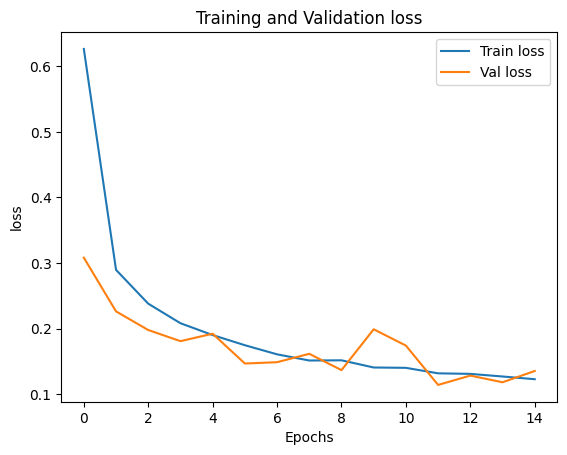

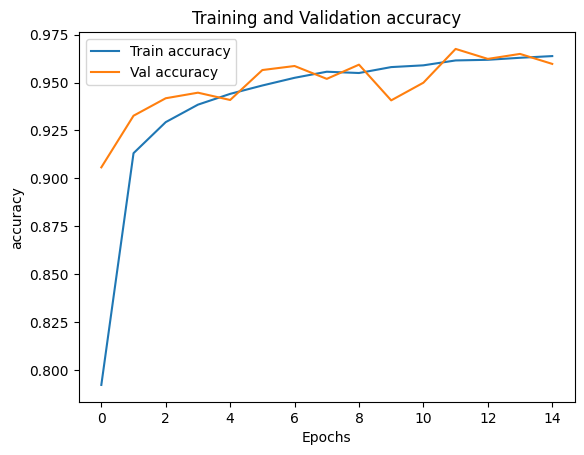

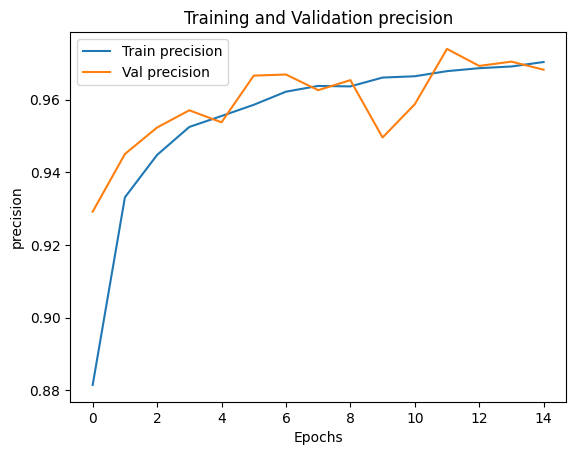

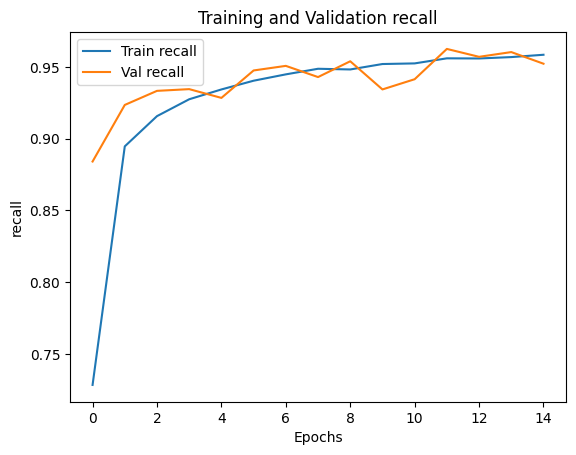

In [32]:
plot_metrics(history)


In [33]:

# Evaluate the model
results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")
print(f"Test Precision: {results[2]}")
print(f"Test Recall: {results[3]}")

Test Loss: 0.1140022799372673
Test Accuracy: 0.9674999713897705
Test Precision: 0.9739931225776672
Test Recall: 0.9624999761581421


In [34]:
model.save("SimpleRNNwithEarlyStopping.keras")

In [35]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 50)             │         3,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,682 (112.04 KB)

 Trainable params: 9,560 (37.34 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,122 (74.70 KB)